# 12-1 Momentum Long/Short Strategy: S&P 500

A cross-sectional momentum backtest on the S&P 500 universe. Each month, stocks are ranked by their 12–1 momentum (return from 12 months ago to 1 month ago, skipping the most recent month to avoid short-term reversal). We go long the top 20%, short the bottom 20%, equal-weight within each leg, and rebalance monthly. The strategy is evaluated over 2011–June 2026. Note: the universe is current S&P 500 membership, so results carry survivorship bias.

The notebook is organized as:

1. **[Data Collection](#1.-Data-Collection)**: pull the S&P 500 ticker list and daily prices
2. **[Signal Construction](#2.-Signal-Construction)**: build monthly prices and the 12–1 momentum score
3. **[Portfolio Construction](#3.-Portfolio-Construction)**: rank, select, and weight the long/short book
4. **[Performance Evaluation](#4.-Performance-Evaluation)**: returns, drawdowns, benchmark comparison, subperiod stability, transaction costs
5. **[Significance Testing (Cross-Sectional Permutation Test)](#5.-Significance-Testing-(Cross-Sectional-Permutation-Test))**: is the Sharpe distinguishable from luck?
6. **[Regime Analysis](#6.-Regime-Analysis)**: behavior across bull/bear and high/low-volatility regimes
7. **[Volatility-Managed Momentum](#7.-Volatility-Managed-Momentum)**: scaling exposure by inverse volatility
8. **[Refinements: Market Exposure and Risk Concentration](#8.-Refinements:-Market-Exposure-and-Risk-Concentration)**: rolling market-beta hedge and inverse-volatility weighting
9. **[Cost Sensitivity](#9.-Cost-Sensitivity)**: how the net edge holds up as transaction costs rise
10. **[Robustness: Lookback-Window Sensitivity](#10.-Robustness:-Lookback-Window-Sensitivity)**: does the edge survive across different momentum lookback windows?

**Note:** Run the notebook top to bottom. Cells share state and later sections depend on variables defined earlier.



## Setup

All imports are found here, and reusable helper functions are defined once below (in order of use).

In [1]:
import pandas as pd
import requests
from io import StringIO
import os
import yfinance as yf
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
def drawdown_duration(x):
    """Count of consecutive periods x spends below its running peak (drawdown length)."""
    peak = x.expanding(min_periods=1).max()
    at_peak = x >= peak               
    grp = at_peak.cumsum()
    return (~at_peak).groupby(grp).cumsum()  

def sharpe(ret):
    """Annualized sharpe ratio of monthly return stream ret"""
    return (ret.mean() * 12)/(ret.std() * np.sqrt(12))

def regress(y, x):
    """OLS of y on x with an intercept. Returns alpha, beta, t_value of alpha"""
    fit = sm.OLS(y, sm.add_constant(x)).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
    return fit.params.iloc[0], fit.params.iloc[1], fit.tvalues.iloc[0]

def scramble(ranks, rng):
    """Row-wise permutation of the non-NaN ranks. Used to build the permutation null."""
    ranks_copy = ranks.to_numpy().copy()
    for r in range(ranks_copy.shape[0]):
        row = ranks_copy[r]
        valid = ~np.isnan(row)                     # positions with a non-NaN ranks
        vals = row[valid]
        rng.shuffle(vals)                          # permute only the valid/non-NaN ranks
        row[valid] = vals                          # writes back into the valid slots
    return pd.DataFrame(ranks_copy, index=ranks.index, columns=ranks.columns)

## 1. Data Collection

Scrape the S&P ticker list from Wikipedia, then download daily adjusted close prices for each ticker from Yahoo Finance over the period 2010-June 2026. 

**Note:** The universe is current S&P 500 membership rather than point-in-time membership, which biases results in two ways. Companies that were in the index during the sample but have since been dropped, acquired, or delisted are excluded, so high-momentum names that later collapsed never appear. Additionally, companies added to the index during the sample are present throughout, including in the years before they qualified. Both effects likely overstate performance, and the distortion is largest in the early years, when today's membership list least resembles the actual index of the time.

In [3]:
# Get the S&P 500 ticker list from Wikipedia
# A browser User Agent is sent so Wikipedia does not block the request
TICKER_FILE = "data/sp500_tickers.csv"

if os.path.exists(TICKER_FILE):
    tickers = pd.read_csv(TICKER_FILE)["ticker"].tolist()
else:
    headers = {"User-Agent": "Mozilla/5.0"}
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    response = requests.get(url, headers=headers)
    table = pd.read_html(StringIO(response.text))
    sp500=table[0]
    tickers=sp500['Symbol'].tolist()
    tickers = [t.replace('.', '-') for t in tickers]
    os.makedirs("data", exist_ok=True)
    pd.Series(tickers, name="ticker").to_csv(TICKER_FILE, index=False)

In [4]:
# download daily adjusted close prices for tickers
# Reproducibility: yfinance pulls live data that drifts over time, so we download
# once and cache to parquet. Later runs load the frozen file, so results stay fixed.

PRICE_FILE_IS = "data/prices_backtest.parquet"

if os.path.exists(PRICE_FILE_IS):
    daily_prices = pd.read_parquet(PRICE_FILE_IS)
else:
    stock_px = yf.download(tickers, start="2010-01-01", end="2026-07-01", auto_adjust=False)
    daily_prices = stock_px["Adj Close"]
    os.makedirs("data", exist_ok=True)
    daily_prices.to_parquet(PRICE_FILE_IS)

In [5]:
# Drop tickers with no data over the full sample
daily_prices = daily_prices.dropna(axis=1, how='all')

## 2. Signal Construction

Resample to month-end prices, then compute the 12–1 momentum score for every stock at each month end: the return from 12 months ago up to 1 month ago. The most recent month is excluded to avoid the effects of short-term (one-month) return reversals and microstructure noise.

In [6]:
# Convert daily prices to monthly using the last trading day of each month
monthly_prices = daily_prices.resample('ME').last()

In [7]:
# Calculate 12-1 momentum score for each stock at each month end
momentum_score = monthly_prices.shift(1)/monthly_prices.shift(12) - 1

## 3. Portfolio Construction

Rank stocks by momentum within each month, select the top and bottom quintiles, and equal-weight within each leg to form a dollar-neutral long/short book.

In [8]:
# Percentile ranking of each stock's momentum within each month
momentum_rank = momentum_score.rank(axis=1, pct=True)

In [9]:
# Identify long candidates (top 20%) and short candidates (bottom 20%)
long_candidates = (momentum_rank>=0.8)*1
short_candidates = (momentum_rank<=0.2)*1

In [10]:
# Count number of long and short positions each month (used for equal weighting)
n_longs = long_candidates.sum(axis=1)
n_shorts = short_candidates.sum(axis=1)

In [11]:
# Equal weight within each leg
long_weights = long_candidates.div(n_longs, axis=0)
short_weights = -short_candidates.div(n_shorts, axis=0)

In [12]:
# Combined dollar-neutral portfolio
portfolio_weights = long_weights + short_weights

## 4. Performance Evaluation

Measure the strategy's risk and return characteristics by computing returns, Sharpe ratio, and drawdowns, comparing performance against the S&P 500 through a market regression, and evaluating the impact of transaction costs on net profitability.

### 4a: Returns

In [13]:
# Monthly portfolio returns
# Weights are lagged one month so we only trade on information available at the prior month end 
# The first 13 months are dropped (12 to form the signal, 1 for the lag) as no valid portfolio weights exist yet.
monthly_returns = monthly_prices.pct_change(fill_method=None)
portfolio_returns = (portfolio_weights.shift(1) * monthly_returns).sum(axis=1)
portfolio_returns = portfolio_returns.iloc[13:]

<Axes: title={'center': 'Cumulative Portfolio Returns'}, xlabel='Date'>

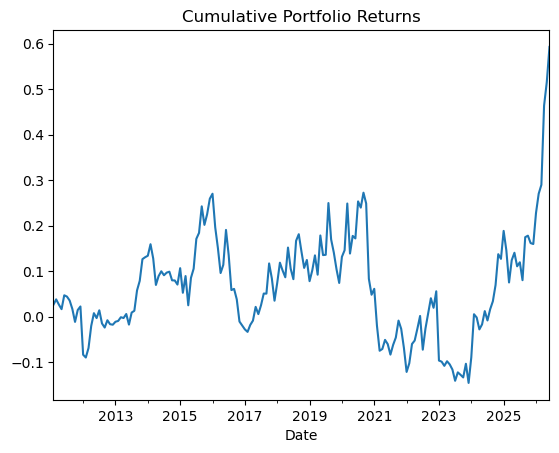

In [14]:
# Cumulative returns
cumulative_returns = (1 + portfolio_returns).cumprod() - 1
cumulative_returns.plot(title = "Cumulative Portfolio Returns")

In [15]:
# Annualized return, volatility, and Sharpe
ann_return = portfolio_returns.mean() * 12
ann_vol = portfolio_returns.std() * np.sqrt(12)
gross_sharpe = sharpe(portfolio_returns)
print(f"Annualized return: {ann_return:.2%}")
print(f"Annualized vol:    {ann_vol:.2%}")
print(f"Gross Sharpe:      {gross_sharpe:.2f}")

Annualized return: 4.01%
Annualized vol:    14.05%
Gross Sharpe:      0.29


#### ANALYSIS

The 12-1 momentum strategy returns 4.01% annualized from 2011 to June 2026, with 14.05% annualized volatility and a gross Sharpe of 0.29. The cumulative curve is driven by a few distinct periods rather than a steady upward trend: the strategy gains through 2013–2016 and again from 2017–2020, but gives back nearly all of it during a prolonged 2021–2024 drawdown. It then rises sharply from 2024 onward to finish roughly 60% above where it started. Almost all of that final gain comes from the last two years, so the full-sample figures are heavily influenced by a short recent stretch - the subperiod breakdown in 4d quantifies this. The overall shape is not that of a consistently present edge but one that may be regime-dependent, motivating the regime analysis later in the project.

### 4b. Drawdowns

In [16]:
# Constructing drawdown series (% below running peak)
wealth = (1 + portfolio_returns).cumprod()
dd = wealth / wealth.cummax() - 1

<Axes: title={'center': 'Drawdown Plot'}, xlabel='Date'>

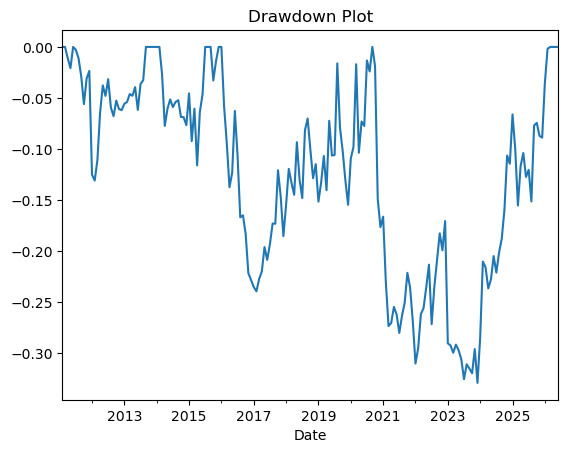

In [17]:
dd.plot(title="Drawdown Plot")

In [18]:
print(f"Maximum Drawdown Size during this period was: {dd.min()}")

Maximum Drawdown Size during this period was: -0.32879913148110207


In [19]:
ddd=drawdown_duration(wealth)

In [20]:
print(f"Longest drawdown duration over the period: {ddd.max()} months")

Longest drawdown duration over the period: 65 months


#### ANALYSIS:

From above, the largest drawdown over the sample was −32.9% below the running peak, and the longest time spent below a prior peak was 65 months. For a strategy with 14.05% annualized volatility and 4.01% annualized return, that is a poor risk profile: the Calmar ratio (annualized return over max drawdown) is roughly 0.12, so the strategy delivers little return per unit of worst case loss. The 65-month figure means it went more than five years without setting a new high, which would be difficult for an investor to tolerate and reinforces that the edge is not consistently present. The strategy peaked in September 2020, fell to its −32.9% trough by December 2023, and spent the entire 2024–2026 rally recovering that ground.

### 4c. Benchmark Comparison

In [21]:
SPX_FILE = "data/spx.parquet"
if os.path.exists(SPX_FILE):
    spx = pd.read_parquet(SPX_FILE)
else:
    spx = yf.download("^GSPC", start="2010-01-01", end="2026-07-01", auto_adjust=False)[["Adj Close"]]
    os.makedirs("data", exist_ok=True)
    spx.to_parquet(SPX_FILE)

spx = spx["Adj Close"]
spx_returns = spx.resample("ME").last().pct_change(fill_method=None).squeeze()

# Pair on common, non-NaN months
bench = pd.concat([portfolio_returns, spx_returns], axis=1).dropna()
bench.columns = ["strat", "spx"]

In [22]:
# Market regression: strat = alpha + beta*market + resid
alpha, beta, t_alpha = regress(bench["strat"], bench["spx"])

spx_sharpe = sharpe(bench["spx"])
neutral_sharpe = sharpe(bench["strat"] - beta * bench["spx"])
corr = bench["strat"].corr(bench["spx"])

print(f"Gross Sharpe (strategy):{gross_sharpe:.2f}")
print(f"S&P 500 Sharpe: {spx_sharpe:.2f}")
print(f"Beta to S&P: {beta:+.3f}")
print(f"Correlation to S&P: {corr:+.3f}")
print(f"Annualized alpha: {alpha*12:+.2%}  (t={t_alpha:.2f})")
print(f"Market-neutral Sharpe: {neutral_sharpe:.2f}")

Gross Sharpe (strategy):0.29
S&P 500 Sharpe: 0.88
Beta to S&P: -0.194
Correlation to S&P: -0.195
Annualized alpha: +6.43%  (t=2.09)
Market-neutral Sharpe: 0.47


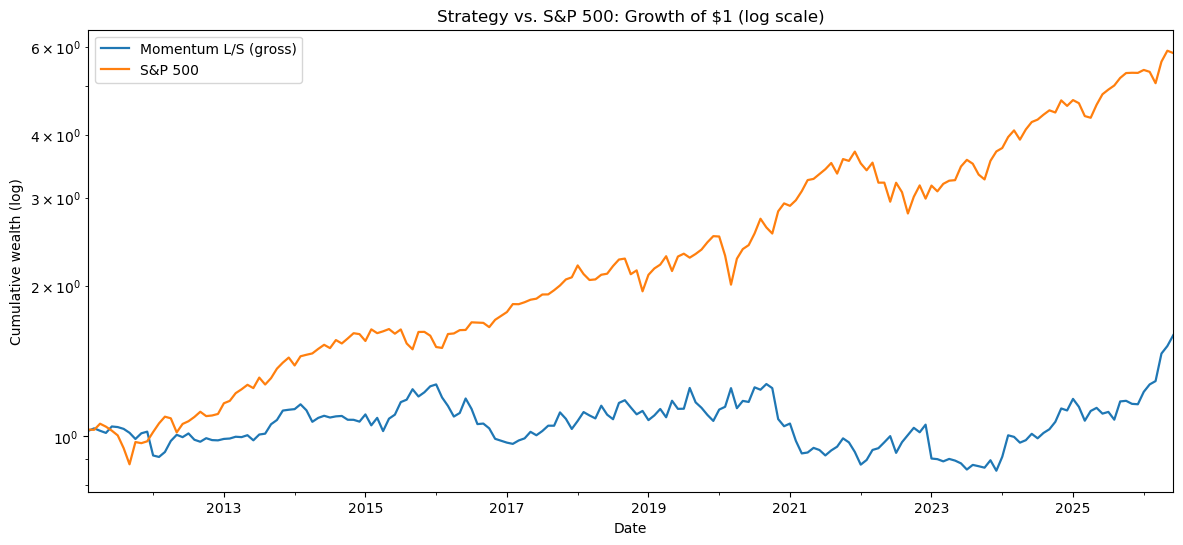

In [23]:
# Growth of $1 for strategy vs. benchmark (on a log scale_
fig, ax = plt.subplots(figsize=(14, 6))
(1 + bench["strat"]).cumprod().plot(ax=ax, label="Momentum L/S (gross)", linewidth=1.6)
(1 + bench["spx"]).cumprod().plot(ax=ax,  label="S&P 500", linewidth=1.6)
ax.set_yscale("log")
ax.set_title("Strategy vs. S&P 500: Growth of $1 (log scale)")
ax.set_ylabel("Cumulative wealth (log)"); ax.legend()
plt.show()

#### ANALYSIS:

The strategy has a beta of −0.194 and a correlation of −0.195 to the S&P 500, so it tends to move mildly against the market. By construction the book is dollar-neutral, meaning equal dollars long and short, however, dollar neutrality does not imply beta neutrality. One likely explanation is that momentum tends to select lower-beta names on the long side and higher-beta names on the short side. Recent losers are often more volatile stocks, while recent winners tend to be steadier, leaving a residual short-market position. Because the S&P rose over most of the sample, that negative beta acted as a drag on returns.

Removing the market component raises the Sharpe from 0.29 to 0.47, suggesting part of the raw strategy's weak performance comes from unintended market exposure rather than the signal itself. The annualized alpha is +6.43% with a t-statistic of 2.09, which clears the conventional 5% threshold. That said, the full-sample beta of −0.194 masks considerable sub-period variation: section 4d shows it ranging from −0.45 to +0.69 across subperiods, so a single number understates how much the book's market exposure moves.

Finally, the graph shows that the S&P 500 substantially outperforms the strategy in absolute terms. Much of that gap reflects risk taken: the index is fully exposed to a rising market while the strategy holds little net market exposure. The two are not competing for the same role - a market-neutral strategy is not meant to beat the index but to provide a return stream largely independent of it, which the low correlation (−0.195) supports.

### 4d. Subperiod Stability

The full-sample figures average over fifteen years and can hide substantial variation. Here we split the sample into four calendar periods and report raw performance, market beta, and market-neutral Sharpe within each, to check whether the edge is consistently present or concentrated in particular stretches.

In [24]:
periods = {
    "2011-2015": ("2011-01-01", "2015-12-31"),
    "2016-2020": ("2016-01-01", "2020-12-31"),
    "2021-2023": ("2021-01-01", "2023-12-31"),
    "2024-2026": ("2024-01-01", "2026-06-30"),
}

# Split the sample into non-overlapping windows and compute Sharpe, beta, and market-neutral Sharpe within each
print(f"{'Period':12}{'Months':>8}{'Ann ret':>10}{'Ann vol':>10}{'Sharpe':>9}{'Beta':>8}   {'Market-Neutral Sharpe':>11}")
for name, (start, end) in periods.items():
    r = portfolio_returns.loc[start:end]
    sub = bench.loc[start:end]
    _, b, _ = regress(sub["strat"], sub["spx"])
    mn = sharpe(sub["strat"] - b * sub["spx"])
    print(f"{name:12}{len(r):>8}{r.mean()*12:>10.2%}{r.std()*np.sqrt(12):>10.2%}"
          f"{sharpe(r):>9.2f}{b:>+8.3f}{mn:>11.2f}")

Period        Months   Ann ret   Ann vol   Sharpe    Beta   Market-Neutral Sharpe
2011-2015         59     5.22%    10.20%     0.51  -0.192       0.72
2016-2020         60    -2.44%    15.75%    -0.16  -0.449       0.25
2021-2023         36    -5.77%    14.29%    -0.40  -0.269      -0.24
2024-2026         30    26.29%    15.27%     1.72  +0.693       1.04


#### ANALYSIS

The strategy's performance is highly uneven across the sample. It works in 2011–2015 (Sharpe 0.51), then loses money for eight consecutive years across 2016–2020 (−0.16) and 2021–2023 (−0.40), before a very strong 2024–2026 (1.72). The full-sample Sharpe of 0.29 is therefore an average of two good stretches and one long bad one, not evidence of a steadily present edge.

After stripping out market exposure, we can see the market-neutral Sharpe is more stable than the raw figure and turns the weak 2016–2020 period positive. This supports the interpretation from 4c: much of the raw variability comes from unintended market exposure rather than the signal. That said, 2021–2023 remains negative even after neutralizing (−0.24), so that period reflects genuine signal failure, not just an adverse beta. Beta itself is unstable in both size and sign, moving from −0.19 to −0.45 to −0.27 and then to +0.69 in the final period. The single full-sample estimate of −0.194 understates how much the book's market exposure varies, which is worth noting for the rolling hedge in section 8a.

Finally, these figures are sensitive to where the period boundaries are drawn. Under an equal four-way split the recent period's Sharpes are notably lower and its beta less positive. The qualitative pattern holds under both cuts, but the specific magnitudes for the recent period should not be read as precise.

### 4e. Transaction Costs

In [25]:
# Apply a per-trade cost to turnover
cost_per_trade = 0.001                              # estimated at 10 bps per side of trade
turnover = (portfolio_weights - portfolio_weights.shift(1)).abs().sum(axis=1)
trading_cost = cost_per_trade * turnover.shift(1)
net_returns = portfolio_returns - trading_cost

net_frame = pd.concat([portfolio_returns, spx_returns, net_returns], axis=1).dropna()
net_frame.columns = ["strat", "spx", "net"]

In [26]:
g_alpha, g_beta, g_t = regress(net_frame["strat"], net_frame["spx"])
n_alpha, n_beta, n_t = regress(net_frame["net"], net_frame["spx"])

print(f"S&P 500 Sharpe : {sharpe(net_frame['spx']):.2f}")
print(f"Avg monthly turnover (one sided) : {turnover.reindex(net_frame.index).mean()/2:.1%}")  # one-sided turnover

print(f"{'':22}{'GROSS':>10}{'NET':>10}")
print(f"{'Sharpe':22}{sharpe(net_frame['strat']):>10.2f}{sharpe(net_frame['net']):>10.2f}")
print(f"{'Beta to S&P':22}{g_beta:>+10.3f}{n_beta:>+10.3f}")
print(f"{'Market-neutral Sharpe':22}{sharpe(net_frame['strat']-g_beta*net_frame['spx']):>10.2f}{sharpe(net_frame['net']-n_beta*net_frame['spx']):>10.2f}")
print(f"{'Annualized alpha':22}{g_alpha*12:>+10.2%}{n_alpha*12:>+10.2%}")
print(f"{'Alpha t-stat':22}{g_t:>10.2f}{n_t:>10.2f}")

S&P 500 Sharpe : 0.88
Avg monthly turnover (one sided) : 46.6%
                           GROSS       NET
Sharpe                      0.29      0.21
Beta to S&P               -0.194    -0.194
Market-neutral Sharpe       0.47      0.39
Annualized alpha          +6.43%    +5.31%
Alpha t-stat                2.09      1.73


#### ANALYSIS:

The strategy trades roughly 93% of the book per month on average (46.6% one-way). Turnover is measured as the change in target weights from month to month. This slightly overstates actual trading, because price moves during the month already push positions part of the way toward the next month's target without any trade. The cost estimate is therefore mildly overstated. At 10 bps per side, this translates into a drag: gross Sharpe falls from 0.29 to 0.21, and the market-neutral Sharpe from 0.47 to 0.39. The annualized alpha declines from +6.43% to +5.31%, with costs consuming roughly 1.1 percentage points per year. The alpha's t-statistic falls from 2.09 to 1.73, so the result no longer clears the conventional 5% threshold once costs are applied. Beta is unchanged at −0.194, as expected: transaction costs reduce returns but do not alter the book's market exposure.

Overall, the strategy's high turnover is the central problem. Momentum requires frequent rebalancing to stay in the top and bottom quintiles, and at this level of turnover, the cost assumption is very important; a modestly higher estimate could erode most of what remains. This motivates the cost-sensitivity analysis in section 9, which tests how the net Sharpe responds across a range of plausible cost assumptions.

## 5. Significance Testing (Cross-Sectional Permutation Test)

To test whether the strategy's Sharpe could have arisen by chance, we shuffle the momentum ranks within each month, thus destroying the link between each stock and its signal while keeping the universe, the number of long/short positions, and realized returns unchanged. We then rebuild the long/short portfolio on these shuffled ranks and record its gross and market-neutral Sharpe. Repeating this 10,000 times gives us a null distribution of Sharpe ratios which we can compare against the realized values.

In [27]:
rng = np.random.default_rng(42)
gross_null, neutral_null = [], []

for i in range(10000):
    scrambled_rank = scramble(momentum_rank,rng)
    
    #  Rebuild portfolio weights using the scrambled rank
    long_c  = (scrambled_rank >= 0.8) * 1
    short_c = (scrambled_rank <= 0.2) * 1
    lw =  long_c.div(long_c.sum(axis=1),  axis=0)
    sw = -short_c.div(short_c.sum(axis=1), axis=0)
    w  = lw + sw

    pr = (w.shift(1) * monthly_returns).sum(axis=1).iloc[13:]

    # Calculate Gross Sharpe
    gross_null.append(sharpe(pr))

    # Calculate Market-neutral Sharpe (stripping away beta component)
    boot_pair = pd.concat([pr, spx_returns], axis=1).dropna()
    boot_pair.columns = ["strat", "spx"]
    _, b, _ = regress(boot_pair["strat"], boot_pair["spx"])
    neutral = boot_pair["strat"] - b * boot_pair["spx"]
    neutral_null.append(sharpe(neutral))

gross_null   = np.array(gross_null)
neutral_null = np.array(neutral_null)

In [28]:
# p-value = fraction of null draws at least as extreme as the realized Sharpe.
p_gross   = (gross_null >= gross_sharpe).mean()
p_neutral = (neutral_null >= neutral_sharpe).mean()
print(f"Gross Sharpe: real {gross_sharpe:.2f}, permutation p = {p_gross:.3f}")
print(f"Market-neutral Sharpe: real {neutral_sharpe:.2f},  permutation p = {p_neutral:.3f}")

Gross Sharpe: real 0.29, permutation p = 0.136
Market-neutral Sharpe: real 0.47,  permutation p = 0.037


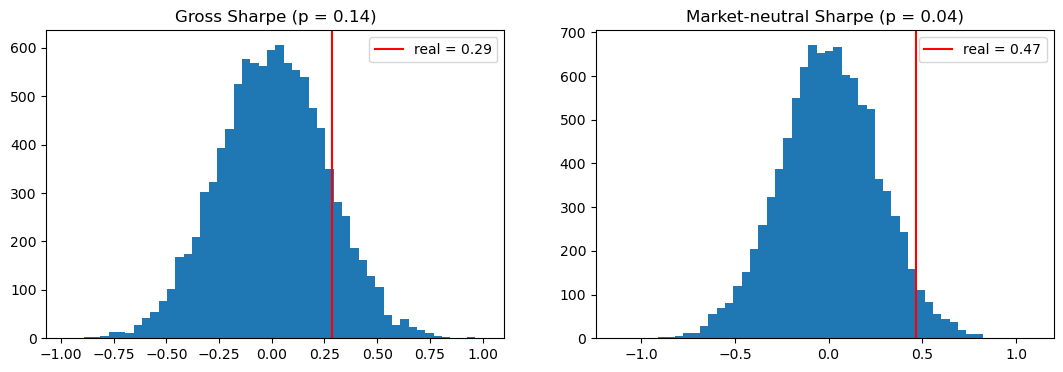

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(gross_null, bins=50)
ax1.axvline(gross_sharpe, color="red", label=f"real = {gross_sharpe:.2f}")
ax1.set_title(f"Gross Sharpe (p = {p_gross:.2f})")
ax1.legend()

ax2.hist(neutral_null, bins=50)
ax2.axvline(neutral_sharpe, color="red", label=f"real = {neutral_sharpe:.2f}")
ax2.set_title(f"Market-neutral Sharpe (p = {p_neutral:.2f})")
ax2.legend()

plt.show()

#### ANALYSIS

Both null distributions are centred near zero and span roughly −1.0 to +1.0, which is what we would expect from a signal with no predictive power. The realized gross Sharpe of 0.29 sits inside the right side of its null distribution: 13.6% of random signals produced a gross Sharpe at least as high, so the gross momentum signal is not distinguishable from chance over this sample. Contrastingly, the market-neutral Sharpe of 0.47 sits much further into the right tail, with only 3.7% of scrambled signals matching or exceeding it, which clears the conventional 5% threshold.

The contrast between the two p-values (0.136 vs 0.037) is a finding worth considering. The same signal appears indistinguishable from noise gross but significant once market exposure is removed, consistent with the regression result in 4c: the strategy's −0.194 beta injects market-driven variation the momentum signal is not responsible for, obscuring the underlying edge.

Two points worth noting on how much weight to put on the market-neutral result. The p-value for the market-neutral sits close enough to 0.05 that it should be read as suggestive rather than firmly established. Additionally, the test is applied to a gross-of-cost Sharpe and section 4e showed the net alpha t-statistic fell below the 5% threshold once trading costs are applied.

## 6. Regime Analysis

Momentum strategies are known to depend heavily on market conditions, performing well in steady environments but prone to momentum crashes in stressed, volatile markets. Here we split the sample by market regime to check whether the strategy's performance is stable or concentrated in particular environments: first by market direction (bull vs. bear), then by volatility level (high vs. low).

### 6a. Bull/Bear

Classify each month by the S&P 500's trailing 12-month return (positive = bull, negative = bear) and compare strategy performance across the two regimes.

In [30]:
# Compute S&P 500 trailing 12-month return
spx_price = spx.resample("ME").last().squeeze()  
trailing_12m = spx_price/spx_price.shift(12)-1
trailing_12m = trailing_12m.dropna(how="all")

# Label each month bull or bear
regime = np.where(trailing_12m > 0, "bull", "bear")
regime = pd.Series(regime, index=trailing_12m.index)

bull_bear_df = pd.concat([portfolio_returns, spx_returns, regime], axis=1).dropna()
bull_bear_df.columns = ["strat", "spx", "regime"]

# Split strategy returns by regime
bull_ret = bull_bear_df[bull_bear_df["regime"] == "bull"]["strat"]
bear_ret = bull_bear_df[bull_bear_df["regime"] == "bear"]["strat"]

In [31]:
print(f"{'':12}{'Bull':>10}{'Bear':>10}")
print(f"{'Months':12}{len(bull_ret):>10}{len(bear_ret):>10}")
print(f"{'Ann return':12}{bull_ret.mean()*12:>10.2%}{bear_ret.mean()*12:>10.2%}")
print(f"{'Sharpe':12}{sharpe(bull_ret):>10.2f}{sharpe(bear_ret):>10.2f}")

                  Bull      Bear
Months             158        27
Ann return       5.23%    -3.12%
Sharpe            0.39     -0.18


In [32]:
# Regress strategy returns on the market within each regime to see whether the alpha and beta differ across bull and bear months.
for r in ["bull", "bear"]:
    sub = bull_bear_df[bull_bear_df["regime"] == r]
    a, b, t = regress(sub["strat"], sub["spx"])
    print(f"{r}: alpha = {a*12:+.2%} (t={t:.2f}), beta = {b:+.2f}")

bull: alpha = +5.74% (t=1.84), beta = -0.03
bear: alpha = -9.47% (t=-1.26), beta = -0.50


#### ANALYSIS

The strategy performs far better in bull markets (Sharpe: 0.39, Annualized return: +5.23%) than in bear markets (Sharpe: −0.18, Annualized return: −3.12%). Regressing within each regime, bull alpha is +5.74% (t=1.84) and bear alpha is −9.47% (t=−1.26). Beta is essentially zero in bull months (−0.030) but strongly negative in bear months (−0.499). The bear-market loss is not a hedging failure, as with the market down 12.7% annualized in those months, the negative beta contributed positively, but instead reflects weaker pure signal performance.

Bull alpha is marginally significant at the 10% level but not at 5%; bear alpha is not significant and the bear sample is only 27 of 185 months. The direction is suggestive of regime-dependence, but because of the small bear sample we cannot establish this. The volatility split below uses a balanced sample and is the more reliable test.

### 6b. Volatility Regime

Split months by whether the S&P 500's trailing 12-month volatility is above or below its median, and compare strategy performance in high vs. low volatility regimes.

In [33]:
# Compute S&P 500 trailing 12-month volatility
rolling_vol = spx_returns.rolling(12).std()
rolling_vol = rolling_vol.dropna(how = "all")

# Label each month high or low vol relative to the sample median
regime_vol =  np.where(rolling_vol > rolling_vol.median(), "high", "low")
regime_vol = pd.Series(regime_vol, index=rolling_vol.index)

vol_regime_df = pd.concat([portfolio_returns, spx_returns, regime_vol], axis=1).dropna()
vol_regime_df.columns = ["strat", "spx", "regime_vol"]

# Split strategy returns by regime
high_vol_ret = vol_regime_df[vol_regime_df["regime_vol"] == "high"]["strat"]
low_vol_ret  = vol_regime_df[vol_regime_df["regime_vol"] == "low"]["strat"]

print(f"{'':12}{'High':>10}{'Low':>10}")
print(f"{'Months':12}{len(high_vol_ret):>10}{len(low_vol_ret):>10}")
print(f"{'Ann return':12}{high_vol_ret.mean()*12:>10.2%}{low_vol_ret.mean()*12:>10.2%}")
print(f"{'Ann vol':12}{high_vol_ret.std()*np.sqrt(12):>10.2%}{low_vol_ret.std()*np.sqrt(12):>10.2%}")
print(f"{'Sharpe':12}{sharpe(high_vol_ret):>10.2f}{sharpe(low_vol_ret):>10.2f}")

                  High       Low
Months              92        93
Ann return       0.63%     7.36%
Ann vol         15.24%    12.78%
Sharpe            0.04      0.58


In [34]:
# Regress strategy returns on the market within each regime to see whether the alpha and beta differ across high and low vol months.
for r in ["high", "low"]:
    sub = vol_regime_df[vol_regime_df["regime_vol"] == r]
    a, b, t = regress(sub["strat"], sub["spx"])
    print(f"{r} vol: alpha = {a*12:+.2%} (t={t:.2f}), beta = {b:+.3f}, {len(sub)} months")

high vol: alpha = +6.07% (t=1.48), beta = -0.382, 92 months
low vol: alpha = +3.74% (t=0.92), beta = +0.335, 93 months


In [35]:
# Average annualized market return within each regime
vol_regime_df.groupby("regime_vol")["spx"].mean() * 12

regime_vol
high    0.142356
low     0.107700
Name: spx, dtype: float64

#### ANALYSIS

Splitting by trailing 12-month market volatility produces a balanced sample (92 high-vol months, 93 low-vol) and a large raw Sharpe gap: 0.58 in low-volatility months versus 0.04 in high-volatility months. On its face this suggests the strategy performs far better in calm markets.

The regressions separate the raw gap into two pieces: market exposure and market-neutral return. Beta swings from +0.335 in low-vol months to −0.382 in high-vol months, and the market rose in both regimes (+10.8% and +14.2% annualized), so the sign flip converts market exposure from a tailwind in calm months into a drag in volatile ones. That accounts for the raw gap. The market-neutral return does not follow it: alpha was +3.74% in low-vol months and +6.07% in high-vol. Neither alpha is significant (t = 0.92 and 1.48), so the difference should not be read as the signal working better in volatile markets. The beta swing is what primarily produces the gap in annual return: the change in market exposure is larger than the 6.7pp raw gap and is partly offset by alpha which runs the other way.

The strategy is riskier in high-volatility months (15.24% vs 12.78% annualized) and earned almost nothing in them (0.63% vs 7.36%), so scaling exposure down when recent volatility is high should cut risk without giving up much return. Trailing volatility is persistent and observable in advance, so this is implementable. The caveat is the alpha result above: if the signal is genuinely stronger in volatile months, scaling down there sacrifices edge. The next section tests a volatility-managed version to see whether it improves risk-adjusted returns and drawdowns in practice.

## 7. Volatility Managed Momentum
The volatility regime split above shows that the strategy carries more risk and earns less in high-volatility months, largely because its market exposure turns against it there. This motivates volatility-managed momentum: rather than holding fixed exposure, we scale positions down when volatility is high and up when it is low.

Here, we scale exposure by the inverse of trailing 12-month volatility, calculated in 6b (larger in calm periods, smaller in turbulent ones). Then rescale so the managed series has the same total volatility as the original, making the two directly comparable on risk-adjusted terms.

In [36]:
# Scale monthly returns by inverse trailing vol (lagged one month to avoid lookahead), then rescale so the managed series matches 
# the original's total volatility
raw_scale = (1 / rolling_vol).shift(1)
managed = portfolio_returns * raw_scale
managed = managed * (portfolio_returns.std() / managed.std()) # rescale to same total vol as original so we can compare apples to apples

In [37]:
# Sharpe, wealth curve, and drawdown for the managed series
managed_gross_sharpe = sharpe(managed)
managed_wealth = (1 + managed).cumprod() 
managed_dd = managed_wealth / managed_wealth.cummax() - 1

# Market-neutral Sharpe
managed_pair = pd.concat([managed, spx_returns], axis=1).dropna()
managed_pair.columns = ["managed_strat", "spx"]
_, managed_beta, _ = regress(managed_pair["managed_strat"], managed_pair["spx"])
managed_neutral = managed_pair["managed_strat"] - managed_beta * managed_pair["spx"]
managed_neutral_sharpe = sharpe(managed_neutral)

print(f"{'':16}{'Original':>10}{'Scaled':>10}")
print(f"{'Gross Sharpe':16}{gross_sharpe:>10.2f}{managed_gross_sharpe:>10.2f}")
print(f"{'Max Drawdown':16}{dd.min():>10.2%}{managed_dd.min():>10.2%}")
print(f"{'Neutral Sharpe':16}{neutral_sharpe:>10.2f}{managed_neutral_sharpe:>10.2f}")

                  Original    Scaled
Gross Sharpe          0.29      0.43
Max Drawdown       -32.88%   -22.46%
Neutral Sharpe        0.47      0.50


In [38]:
# Beta comparison
print(f"original beta: {beta:+.3f}, managed beta: {managed_beta:+.3f}")

original beta: -0.194, managed beta: -0.080


#### ANALYSIS

Holding total volatility equal, vol-scaling raises the gross Sharpe from 0.29 to 0.43 and cuts max drawdown from −32.9% to −22.5%. It also pulls beta toward zero (-0.194 to −0.080), since scaling down in high-vol months reduces exposure in exactly the periods where the book's negative beta was largest. Almost all of the gross-Sharpe gain is the reduced market exposure, not a better signal, as can be seen from the market-neutral Sharpe improving from 0.47 to just 0.50. The drawdown reduction is the clearest benefit. For a market-neutral mandate the 0.03 Sharpe gain is small, so whether the added complexity is worth it depends on whether drawdown control matters for the use case.

Note: the rescaling constant uses full-sample volatility, so it is not implementable in real time. This is deliberate, the purpose is a like-for-like risk comparison, not a tradeable rule.

## 8. Refinements: Market Exposure and Risk Concentration

The book so far is equal-weighted and dollar-neutral, which leaves two remaining problems visible in section 4: a persistent negative market beta, and risk concentrated in the most volatile names. Here we address each separately. First, a rolling market-beta hedge: rather than re-sizing the legs, we leave the momentum book untouched and overlay a monthly index short sized to its rolling beta, neutralizing market exposure without distorting the signal. Second, inverse-volatility weighting within each leg, so that volatile names don't dominate the book's risk.

### 8a. Rolling Market-Beta Hedge

In [39]:
# rolling beta of the raw strategy vs market, using only past data
roll_cov = portfolio_returns.rolling(36).cov(spx_returns)
roll_var = spx_returns.rolling(36).var()
port_beta = (roll_cov / roll_var).shift(1)

# Overlay a market short sized to the rolling beta; regress the hedged series on the market to verify residual beta is near zero
bn_returns = (portfolio_returns - port_beta * spx_returns).dropna()
bn_pair = pd.concat([bn_returns, spx_returns], axis=1).dropna()
bn_pair.columns = ["bn", "spx"]
_, bn_beta, _ = regress(bn_pair["bn"], bn_pair["spx"])

print(f"Baseline beta: {beta:+.3f}   ->  Beta-neutral beta: {bn_beta:+.3f}")
print(f"Baseline gross Sharpe: {gross_sharpe:.2f}   ->  Beta-neutral Sharpe: {sharpe(bn_returns):.2f}")

Baseline beta: -0.194   ->  Beta-neutral beta: +0.048
Baseline gross Sharpe: 0.29   ->  Beta-neutral Sharpe: 0.48


In [40]:
# Cost of trading the hedge overlay: change in beta × market cost
hedge_turnover = port_beta.diff().abs()
hedge_cost     = cost_per_trade * hedge_turnover
bn_net_returns = (net_returns - port_beta * spx_returns - hedge_cost).dropna()

# Regress the net beta-neutral series on the market to find residual beta after costs
bn_net_pair = pd.concat([bn_net_returns, spx_returns], axis=1).dropna()
bn_net_pair.columns = ["bn_net", "spx"]
_, bn_beta_2, _ = regress(bn_net_pair["bn_net"], bn_net_pair["spx"])

print(f"Beta-neutral beta:            {bn_beta_2:+.3f}")
print(f"Beta-neutral Sharpe (gross):  {sharpe(bn_returns):.2f}")
print(f"Beta-neutral Sharpe (net):    {sharpe(bn_net_returns):.2f}")
print(f"  vs. baseline gross Sharpe:  {gross_sharpe:.2f}")
print(f"  vs. baseline net Sharpe:    {sharpe(net_returns):.2f}")

Beta-neutral beta:            +0.046
Beta-neutral Sharpe (gross):  0.48
Beta-neutral Sharpe (net):    0.39
  vs. baseline gross Sharpe:  0.29
  vs. baseline net Sharpe:    0.21


#### ANALYSIS

This section hedges the market exposure by subtracting a rolling 36-month beta (estimated only from past data, lagged one month) times the market return from the strategy's returns each month. Doing so raises the gross Sharpe from 0.29 to 0.48 and drives the realized beta to +0.046, around 0. This is consistent with the 0.47 market-neutral estimate from 4c. Two independent methods of removing the beta landing in the same range is reassuring, since it suggests the recovered alpha is a property of the strategy, not a result of how the hedge was constructed. The raw book ran a −0.194 beta, likely because the short leg holds recent losers, which tend to be higher-beta, jumpier names; being short them tilts the book against the market. Since return ≈ beta × market + alpha, holding a negative beta while the S&P rose over most of the sample was a persistent drag, so removing it recovers the underlying momentum alpha.

After both stock-leg costs and the cost of trading the hedge, the net beta-neutral Sharpe is 0.39, down from 0.48 gross, and above the baseline net of 0.21 (so the improvement survives costs). 

### 8b. Inverse-Volatility Weighting

In [41]:
# Weight each stock in each leg by inverse trailing 12-month vol, so calmer names carry more weight and volatile names carry less
stock_vol = monthly_returns.rolling(12).std()
inv_vol   = 1 / stock_vol
long_w = (long_candidates * inv_vol).div((long_candidates * inv_vol).sum(axis=1),axis=0)
short_w = -(short_candidates * inv_vol).div((short_candidates * inv_vol).sum(axis=1),axis=0)
vol_weights = (long_w+short_w).dropna(how="all").fillna(0.0)

In [42]:
# Apply weights to next month's returns; drop first 13 months to skip warmup
vol_returns = (vol_weights.shift(1) * monthly_returns).sum(axis=1).iloc[13:]

# Regress inverse-vol series on the market for beta comparison
vr_pair = pd.concat([vol_returns, spx_returns], axis=1).dropna()
vr_pair.columns = ["vol", "spx"]
_, vol_beta, _ = regress(vr_pair["vol"], vr_pair["spx"])

print(f"{'':22}{'Equal-wt':>10}{'Inv-vol':>10}")
print(f"{'Gross Sharpe':22}{gross_sharpe:>10.2f}{sharpe(vol_returns):>10.2f}")
print(f"{'Beta to S&P':22}{beta:>+10.3f}{vol_beta:>+10.3f}")
print(f"{'Max Drawdown':22}{dd.min():>10.2%}{(( (1+vol_returns).cumprod() / (1+vol_returns).cumprod().cummax() - 1).min()):>10.2%}")

                        Equal-wt   Inv-vol
Gross Sharpe                0.29      0.17
Beta to S&P               -0.194    -0.203
Max Drawdown             -32.88%   -36.55%


#### ANALYSIS

From our analysis, we can see that weighting each leg by inverse volatility, so calmer names carry more weight, reduces performance rather than improving it. The gross Sharpe falls from 0.29 to 0.17 and max drawdown deepens from −32.9% to −36.6%, while beta is essentially unchanged (−0.194 to −0.203) as expected, since re-weighting within the legs doesn't change market exposure. One likely explanation, which this analysis does not directly test, is that momentum's return concentrates in the most volatile names within each leg, so down-weighting them cuts exposure to the stocks driving returns. Confirming that would require decomposing returns by volatility bucket, which we leave to future work.

## 9. Cost Sensitivity

Our net results so far assume a single transaction-cost estimate (10 bps per side). But that number is itself a judgment call, and the raw net edge sits close to break-even - so the whole picture could be dependent on whether that assumption is optimistic. Here we stress-test it: we recompute net Sharpe across a range of per-side costs to see how far the edge survives before it disappears. This tells us whether the strategy's profitability is a robust feature or a result of a favorable cost assumption, and it identifies the break-even cost i.e the level at which trading eats the entire signal.

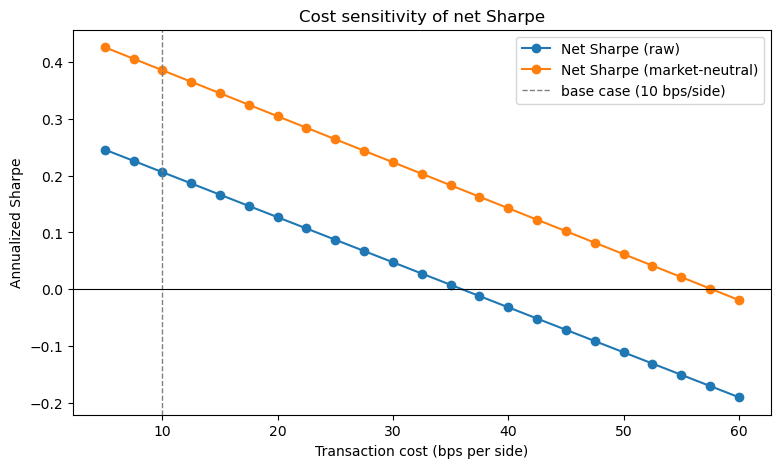

In [43]:
# Sweep per-side costs from 5 to 60 bps and compute monthly turnover
raw_net, market_neutral_net = [], []
cost_range = np.arange(0.0005, 0.00625, 0.00025)
turnover = (portfolio_weights - portfolio_weights.shift(1)).abs().sum(axis=1)

# For each cost level, compute net returns and find raw and market-neutral Sharpe
for c in cost_range:
    net_c = portfolio_returns - c * turnover.shift(1)
    cost_frame = pd.concat([net_c, spx_returns], axis=1).dropna()
    cost_frame.columns = ["net", "spx"]
    _, b, _ = regress(cost_frame["net"], cost_frame["spx"])
    raw_net.append(sharpe(cost_frame["net"]))
    market_neutral_net.append(sharpe(cost_frame["net"] - b * cost_frame["spx"]))  

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cost_range * 1e4, raw_net, marker="o", label="Net Sharpe (raw)")
ax.plot(cost_range * 1e4, market_neutral_net,  marker="o", label="Net Sharpe (market-neutral)")
ax.axvline(10, color="grey", ls="--", lw=1, label="base case (10 bps/side)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Transaction cost (bps per side)")
ax.set_ylabel("Annualized Sharpe")
ax.set_title("Cost sensitivity of net Sharpe")
ax.legend()
plt.show()

#### ANALYSIS

Net Sharpe declines roughly linearly with per-side cost, but the raw and market-neutral lines break even at very different points. The raw net Sharpe crosses zero at ~36 bps/side, so the raw strategy is not cost-fragile - it tolerates costs well above realistic large-cap trading frictions (5–15 bps/side). The market-neutral net Sharpe stays positive out to ~57 bps/side and sits at ~0.39 at the 10 bps base case, so the edge is robust to the cost assumption. 

## 10. Robustness: Lookback-Window Sensitivity

The whole 2011–2026 sample was used to design and evaluate the strategy, so strong results could reflect overfitting to a specific parameter choice rather than a real edge. This section tests one form of that risk: lookback-window sensitivity. We vary the momentum lookback from 3 to 18 months to check whether the chosen 12-month window is a lucky peak or whether nearby windows work about as well. This is a limited robustness test (it doesn't address overfitting on other dimensions like quintile cutoffs or holding period) but it's a useful sanity check on the single parameter most likely to be curve-fit.

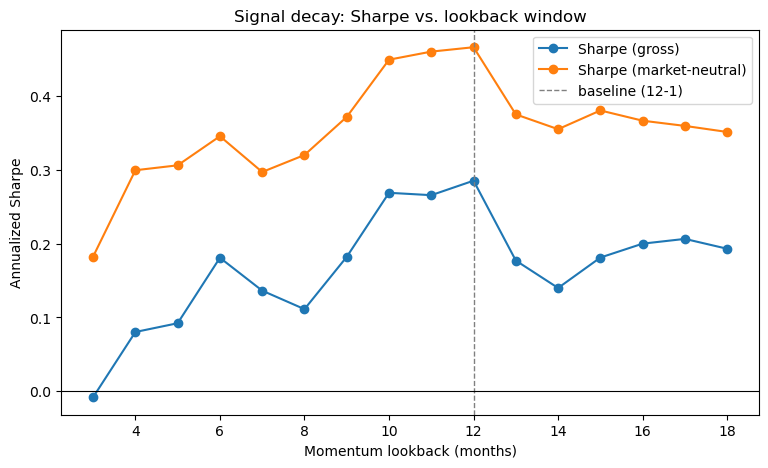

In [44]:
# Sweep momentum lookback from 3 to 18 months
gross_sharpes, market_neutral_sharpes = [], []
windows = np.arange(3,19,1)

# For each window, rebuild the top/bottom-quintile long-short book and record its returns
for w in windows:
    m_score=monthly_prices.shift(1)/monthly_prices.shift(w) - 1
    m_rank = m_score.rank(axis=1, pct=True)
    longs  = (m_rank >= 0.8) * 1
    shorts = (m_rank <= 0.2) * 1
    long_w  = longs.div(longs.sum(axis=1), axis=0)
    short_w = -shorts.div(shorts.sum(axis=1), axis=0)
    portfolio_w = long_w+short_w
    p_ret = (portfolio_w.shift(1) * monthly_returns).sum(axis=1).iloc[w+1:]

# Regress on market to record gross Sharpe and market-neutral Sharpe
    window_frame = pd.concat([p_ret, spx_returns], axis=1).dropna()
    window_frame.columns = ["strat", "spx"]
    _, b, _ = regress(window_frame["strat"], window_frame["spx"])
    gross_sharpes.append(sharpe(window_frame["strat"]))
    market_neutral_sharpes.append(sharpe(window_frame["strat"] - b * window_frame["spx"]))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(windows, gross_sharpes, marker="o", label="Sharpe (gross)")
ax.plot(windows, market_neutral_sharpes,    marker="o", label="Sharpe (market-neutral)")
ax.axvline(12, color="grey", ls="--", lw=1, label="baseline (12-1)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Momentum lookback (months)")
ax.set_ylabel("Annualized Sharpe")
ax.set_title("Signal decay: Sharpe vs. lookback window")
ax.legend()
plt.show()

#### ANALYSIS

The 12-month lookback is not sharply peaked. Market-neutral Sharpe is roughly flat across 10, 11, and 12 months at ~0.45–0.47, so the exact choice within that range doesn't matter. Longer windows stay positive but drift lower to ~0.35–0.38 across 13–18. Short windows are clearly worse: performance declines steadily as the lookback shrinks, with gross Sharpe crossing zero at 3 months - consistent with short-horizon reversal weakening the signal at very short lookbacks. That the result holds across a range of look-back periods rather than at a single choice is mild evidence it isn't the result of one arbitrary parameter choice.